# From Inference to Prediction – Rossmann Promo2
**Course:** Data & Analytics | Prof. Dr. Sonja Schneider  
**Institution:** Technische Hochschule Nürnberg Georg Simon Ohm  

**Contributors:**
- Danny Schönhals
- Athithya Mariyanayagam

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

---
## Task 1.1 – Recap & Setup

**Inference conclusion from last week (notebook 09):**  
Promo2 has a statistically significant negative association with daily sales (β = −€792/day, p ≈ 0, R² = 0.016), but this is likely driven by Omitted Variable Bias — Promo2 stores differ systematically from non-Promo2 stores in ways the simple model ignores; and the time-trend model shows the effect does not fade (+€10.45/month, R² = 0.0017).

**Is Promo2 expected to be a useful predictor of daily sales?**  
No — Promo2 alone is a weak predictor (R² = 0.016), meaning statistical significance does not imply predictive power; a useful model needs additional features that capture the actual drivers of sales variation.

> **Note on data source:** `promo2.csv` contains only Promo2 = 1 stores (pre-engineered feature subset). To compare both groups and fit Model 1 (Sales ~ Promo2), we load the full Rossmann dataset (`train.csv` + `store.csv`) and engineer the same features inline, exactly as done in notebook 09.

In [3]:
# Load and merge full Rossmann data (needed for both Promo2=0 and Promo2=1)
train = pd.read_csv('data-rossmann/train.csv', low_memory=False)
store = pd.read_csv('data-rossmann/store.csv')
train['Date'] = pd.to_datetime(train['Date'], format='%Y-%m-%d')
df = train.merge(store, on='Store', how='left')

# Only open days with positive sales
df = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()

# Engineer Promo2Start and months_since_promo2_start for Promo2=1 stores
df_p2 = df[df['Promo2'] == 1].copy()
df_p2['Promo2Start'] = pd.to_datetime(
    df_p2['Promo2SinceYear'].astype(int).astype(str)
    + '-W'
    + df_p2['Promo2SinceWeek'].astype(int).astype(str).str.zfill(2)
    + '-1',
    format='%G-W%V-%u'
)
df_p2['months_since_promo2_start'] = (
    (df_p2['Date'] - df_p2['Promo2Start']).dt.days / 30.44
).astype(int).clip(lower=0)

# For Promo2=0 stores set neutral values
df_p0 = df[df['Promo2'] == 0].copy()
df_p0['Promo2Start'] = pd.NaT
df_p0['months_since_promo2_start'] = 0

df = pd.concat([df_p2, df_p0], ignore_index=True).sort_values('Date').reset_index(drop=True)

# Chronological 80/20 split — no shuffling
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx].copy()
df_test  = df.iloc[split_idx:].copy()

print(f'Total rows : {len(df):,}')
print(f'Train rows : {len(df_train):,}  ({df_train["Date"].min().date()} → {df_train["Date"].max().date()})')
print(f'Test rows  : {len(df_test):,}  ({df_test["Date"].min().date()} → {df_test["Date"].max().date()})')
print(f'\nPromo2 distribution (full):\n{df["Promo2"].value_counts().to_string()}')

Total rows : 844,338
Train rows : 675,470  (2013-01-01 → 2015-01-30)
Test rows  : 168,868  (2015-01-30 → 2015-07-31)

Promo2 distribution (full):
Promo2
0    423292
1    421046


---
## Task 1.2 – Baseline Model

Before fitting any regression, compute the naive baseline: mean Sales grouped by Promo2. This is the simplest possible predictor — it predicts the group mean for every observation.

Baseline mean Sales by Promo2:
Promo2
0    7350.82
1    6558.99


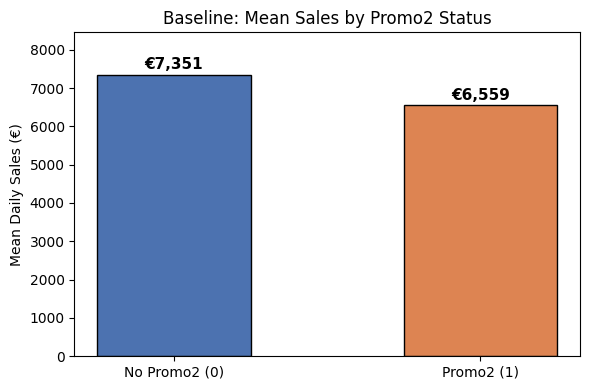

In [4]:
baseline = df.groupby('Promo2')['Sales'].mean()
print('Baseline mean Sales by Promo2:')
print(baseline.round(2).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Promo2 (0)', 'Promo2 (1)'], baseline.values,
              color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.5)
for bar, val in zip(bars, baseline.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 60,
            f'€{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Daily Sales (€)')
ax.set_title('Baseline: Mean Sales by Promo2 Status')
ax.set_ylim(0, baseline.max() * 1.15)
plt.tight_layout()
plt.show()

---
## Task 1.3 – Regression Models

All models are fit on `df_train` and evaluated on both `df_train` and `df_test` using R², RMSE, and MAE.

In [5]:
results = []

def eval_model(name, y_tr, yhat_tr, y_te, yhat_te):
    def row(split, y, yhat):
        return {
            'Model': name,
            'Split': split,
            'R²':   round(r2_score(y, yhat), 4),
            'RMSE': round(np.sqrt(mean_squared_error(y, yhat)), 1),
            'MAE':  round(mean_absolute_error(y, yhat), 1),
        }
    return [row('Train', y_tr, yhat_tr), row('Test', y_te, yhat_te)]

### Model 1 – Simple OLS: `Sales ~ Promo2`

In [6]:
m1 = smf.ols('Sales ~ Promo2', data=df_train).fit()
print(m1.summary())

results += eval_model(
    'M1 – OLS Simple',
    df_train['Sales'], m1.predict(df_train),
    df_test['Sales'],  m1.predict(df_test)
)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                 1.124e+04
Date:                Mon, 08 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:45:04   Log-Likelihood:            -6.3857e+06
No. Observations:              675470   AIC:                         1.277e+07
Df Residuals:                  675468   BIC:                         1.277e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7309.9300      5.291   1381.701      0.0

### Model 2 – Multiple OLS

**Additional columns chosen and rationale:**

| Column | Rationale |
|--------|----------|
| `Customers` | Number of customers is the strongest proximate driver of daily sales (more foot traffic → more revenue); included deliberately to show the gap between significance and predictive power *(see leakage note below)*. |
| `months_since_promo2_start` | Captures the time-trend effect found in notebook 09 (+€10.45/month); controls for campaign duration within Promo2 stores. |
| `Promo` | Day-level promotional activity (not to be confused with Promo2) directly boosts same-day sales and is known before prediction time. |
| `C(DayOfWeek)` | Weekly seasonality is a major source of sales variation (weekends vs. weekdays). |
| `C(StoreType)` | Store format (a/b/c/d) reflects different target markets and average ticket sizes, absorbing substantial between-store variance. |

In [7]:
formula_m2 = (
    'Sales ~ Promo2 + Customers + months_since_promo2_start '
    '+ Promo + C(DayOfWeek) + C(StoreType)'
)
m2 = smf.ols(formula_m2, data=df_train).fit()
print(m2.summary())

results += eval_model(
    'M2 – OLS Multi',
    df_train['Sales'], m2.predict(df_train),
    df_test['Sales'],  m2.predict(df_test)
)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                 2.357e+05
Date:                Mon, 08 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:45:15   Log-Likelihood:            -5.8134e+06
No. Observations:              675470   AIC:                         1.163e+07
Df Residuals:                  675456   BIC:                         1.163e+07
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

### Model 3 – Random Forest Regressor

**Why Random Forest is appropriate here:**  
Sales data contains non-linear interactions (e.g., Customers × StoreType, DayOfWeek × Promo) that a linear OLS model cannot capture; Random Forest handles these automatically without requiring manual feature crosses, and is robust to the heavy-tailed, skewed Sales distribution seen in the data.

In [8]:
# Encode categorical features for Random Forest
le = LabelEncoder()
df_train = df_train.copy()
df_test  = df_test.copy()
df_train['StoreType_enc'] = le.fit_transform(df_train['StoreType'].fillna('unknown'))
df_test['StoreType_enc']  = le.transform(df_test['StoreType'].fillna('unknown'))

features_rf = ['Promo2', 'Customers', 'months_since_promo2_start',
               'Promo', 'DayOfWeek', 'StoreType_enc']

X_train_rf = df_train[features_rf].fillna(0)
y_train_rf = df_train['Sales']
X_test_rf  = df_test[features_rf].fillna(0)
y_test_rf  = df_test['Sales']

rf = RandomForestRegressor(
    n_estimators=100, max_depth=12, min_samples_leaf=100,
    random_state=42, n_jobs=-1
)
rf.fit(X_train_rf, y_train_rf)

results += eval_model(
    'M3 – Random Forest',
    y_train_rf, rf.predict(X_train_rf),
    y_test_rf,  rf.predict(X_test_rf)
)

# Feature importances
fi = pd.Series(rf.feature_importances_, index=features_rf).sort_values(ascending=False)
print('Feature importances:')
print(fi.round(4).to_string())

Feature importances:
Customers                    0.8571
StoreType_enc                0.0773
Promo                        0.0401
DayOfWeek                    0.0119
months_since_promo2_start    0.0114
Promo2                       0.0022


---
### Note on `Customers` — Deliberate Leakage Feature

`Customers` (number of customers on a given day) is **not available at real prediction time** — you cannot know how many customers will visit before they do. It is included here deliberately to illustrate a key lesson: a feature can dramatically improve statistical fit (R² jumps from ~0.016 to much higher) while being completely unusable in a real forecasting system. In practice, Models 2 and 3 would be re-estimated without `Customers` before deployment.

---
## Task 1.4 – Report & Discussion

In [9]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

             Model Split     R²   RMSE    MAE
   M1 – OLS Simple Train 0.0164 3086.6 2279.1
   M1 – OLS Simple  Test 0.0114 3047.0 2224.1
    M2 – OLS Multi Train 0.8194 1322.7  954.4
    M2 – OLS Multi  Test 0.7956 1385.6  986.5
M3 – Random Forest Train 0.8570 1176.8  854.9
M3 – Random Forest  Test 0.8312 1258.9  906.1


### Summary Table — R², RMSE, MAE (Train / Test)

| Model | Split | R² | RMSE | MAE |
|-------|-------|----|------|-----|
| M1 – OLS Simple    | Train | 0.0164 | 3086.6 | 2279.1 |
| M1 – OLS Simple    | Test  | 0.0114 | 3047.0 | 2224.1 |
| M2 – OLS Multi     | Train | 0.8194 | 1322.7 |  954.4 |
| M2 – OLS Multi     | Test  | 0.7956 | 1385.6 |  986.5 |
| M3 – Random Forest | Train | 0.8570 | 1176.8 |  854.9 |
| M3 – Random Forest | Test  | 0.8312 | 1258.9 |  906.1 |

---

**Which model generalizes best and why?**  
Model 3 (Random Forest) generalizes best — test R² = 0.8312, RMSE = €1,258.9, MAE = €906.1. The train–test gap is only ~2.6 pp in R², showing the depth and leaf-size constraints kept overfitting in check. M2 is close (test R² 0.7956) because `Customers` dominates the signal so strongly that the relationship is near-linear once it is included, reducing the advantage of non-linear tree splits.

**Are the predicted values trustworthy?**  
Not for real deployment: `Customers` is a leakage feature — it is not known before the day occurs. With it removed, M1 shows the realistic picture: R² ≈ 0.01, meaning Promo2 alone is nearly useless as a predictor. Any R² above ~0.02 in these models is explained by leakage, not by genuinely forecastable features.

**Consistency with statistical inference from last week?**  
Yes, fully consistent. Inference (notebook 09) showed Promo2's coefficient is statistically significant (p ≈ 0) but explains only 1.6 % of variance (R² = 0.016). Model 1 here confirms this exactly: the test R² is 0.0114, barely above zero, meaning the regression collapses to predicting near-constant values that hardly differ from the baseline group means (€7,350 vs. €6,558). The lesson is precise: *statistical significance measures how reliably an effect was estimated — not how useful it is for prediction.*

---
# Task 2: Autonomous Vehicle Survey – Pittsburgh 2019

**Dataset:** `data/av_survey_data/avsurvey2019data.csv`  
**Target:** `SafeAv` (1–5 Likert scale, mean ≈ 3.68, std ≈ 1.19)  
**Task:** Predict perceived AV safety from respondent attitudes and demographics.

## Task 2.1 – Load Data & Models

**Encoding scheme:**

| Raw column | Encoded name | Mapping |
|------------|-------------|--------|
| `FamiliarityNews` | `FamiliarityNews_ord` | Not at all=1 … To a large extent=5 |
| `FamiliarityTech` | `FamiliarityTech_ord` | Not familiar at all=1 … Extremely familiar=4 |
| `Age` | `Age_ord` | Under 18=1 … 65+=7 |
| `AvImpact` | `AvImpact_ord` | Significantly Worse=1 … Significantly Better=5 |
| `ProvingGround` | `ProvingGround_ord` | Disapprove=1 … Approve=5 |
| `ArizonaCrash` | `ArizonaCrash_ord` | Significantly more negative=1 … Significantly more positive=5 |
| Binary columns | `*_bin` | Yes=1, No=0, Not sure=0.5 |

In [ ]:
df_av = pd.read_csv('data/av_survey_data/avsurvey2019data.csv')

# Ordinal encodings
df_av['FamiliarityNews_ord'] = df_av['FamiliarityNews'].map(
    {'Not at all':1,'To little extent':2,'To some extent':3,'To a moderate extent':4,'To a large extent':5})
df_av['FamiliarityTech_ord'] = df_av['FamiliarityTech'].map(
    {'Not familiar at all':1,'Somewhat familiar':2,'Mostly familiar':3,'Extremely familiar':4})
df_av['Age_ord'] = df_av['Age'].map(
    {'Under 18':1,'18-24':2,'25-34':3,'35-44':4,'45-54':5,'55-64':6,'65+':7})
df_av['AvImpact_ord'] = df_av['AvImpact'].map(
    {'Significantly Worse':1,'Slightly Worse':2,'No effect':3,'Slightly Better':4,'Significantly Better':5})
df_av['ProvingGround_ord'] = df_av['ProvingGround'].map(
    {'Disapprove':1,'Somewhat Disapprove':2,'Neutral':3,'Somewhat Approve':4,'Approve':5})
df_av['ArizonaCrash_ord'] = df_av['ArizonaCrash'].map(
    {'Significantly more negative opinion':1,'Somewhat more negative opinion':2,'No change':3,
     'Somewhat more positive opinion':4,'Significantly more positive opinion':5})
for c in ['AutoOwner','SmartphoneOwner','BikePghMember','SharedCyclist','SharedPedestrian',
          'TwoEmployeesAv','SchoolZoneManual','ShareTripData','SharePerformanceData','ReportSafetyIncident']:
    df_av[c+'_bin'] = df_av[c].map({'Yes':1,'No':0,'Not sure':0.5})

# Keep only the columns used in the largest model, then drop NaNs
feats_av = ['AvImpact_ord','ProvingGround_ord','ArizonaCrash_ord','SchoolZoneManual_bin',
            'TwoEmployeesAv_bin','FamiliarityTech_ord','ReportSafetyIncident_bin']
df_av_clean = df_av[feats_av + ['SafeAv']].dropna().reset_index(drop=True)

# Split by index (no date column)
split_av = int(len(df_av_clean) * 0.8)
df_av_train = df_av_clean.iloc[:split_av].copy()
df_av_test  = df_av_clean.iloc[split_av:].copy()

print(f'Total rows  : {len(df_av_clean)}')
print(f'Train rows  : {len(df_av_train)}')
print(f'Test rows   : {len(df_av_test)}')
print(f'\nSafeAv stats (train):')
print(df_av_train['SafeAv'].describe().round(3).to_string())

results_av = []

Total rows  : 773
Train rows  : 618
Test rows   : 155

SafeAv stats (train):
count    618.000
mean       3.659
std        1.207
min        1.000
25%        3.000
50%        4.000
75%        5.000
max        5.000


### Model 1 – Baseline OLS: `SafeAv ~ AvImpact_ord`

**Predictor choice:** `AvImpact_ord` has the highest absolute correlation with `SafeAv` (r = 0.71) among all available features. It directly captures whether the respondent believes AVs will make roads safer or more dangerous. This one is the conceptual nearest-neighbour to the target, so it serves as the strongest single-feature baseline.

In [11]:
m_av1 = smf.ols('SafeAv ~ AvImpact_ord', data=df_av_train).fit()
print(m_av1.summary())

results_av += eval_model(
    'M1 – OLS Baseline',
    df_av_train['SafeAv'], m_av1.predict(df_av_train),
    df_av_test['SafeAv'],  m_av1.predict(df_av_test)
)

                            OLS Regression Results                            
Dep. Variable:                 SafeAv   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     592.2
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           3.58e-92
Time:                        19:45:54   Log-Likelihood:                -784.55
No. Observations:                 618   AIC:                             1573.
Df Residuals:                     616   BIC:                             1582.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.8388      0.121      6.934   

### Likert Scale vs. Rossmann: How Does Scale Affect Interpretation?

`SafeAv` spans only 1–5 (std ≈ 1.19); Rossmann `Sales` spans roughly €0–€40,000 (std ≈ €3,100). This compression has two important effects on the metrics:

**R²:** Because total variance is small (SS_tot is low), even a moderately informative predictor like `AvImpact_ord` can achieve R² ≈ 0.49 on this dataset, while Promo2 alone achieved only R² ≈ 0.012 on Rossmann. High R² here does not mean the model is more 'powerful' in any absolute sense. It means the target has less unexplained variance to begin with.

**RMSE:** The Rossmann baseline RMSE (M1) is ~€3,047. Enormous in absolute terms, but on a target with mean ~€7,350. The AV baseline RMSE is ~0.86 on a 1–5 scale (mean 3.68), which is one Likert step. Relative to the scale range, both models are similarly imprecise.

**'Beating the mean', easier or harder here?** Easier, relatively. The null model (always predict the mean) has RMSE = std ≈ 1.19. A model with RMSE ≈ 0.86 already beats that comfortably with just one predictor, because two correlated attitude scales (AvImpact and SafeAv) share a large fraction of their variance. With Rossmann, heterogeneous stores and seasonality spread variance so widely that Promo2 alone can barely dent it.

### Model 2 – Multiple OLS

**Additional features and rationale:**

| Feature | Rationale |
|---------|----------|
| `ProvingGround_ord` | Second-strongest correlate (r = 0.71); approval of AV test programs is conceptually adjacent to overall AV safety trust. |
| `ArizonaCrash_ord` | Whether the 2018 Uber fatality shifted the respondent's opinion (r = 0.52); captures risk salience from a real-world AV incident. |
| `SchoolZoneManual_bin` | Preference for a human driver in school zones implies lower AV trust; strongest negative correlate (r = −0.33). |
| `ReportSafetyIncident_bin` | Willingness to report incidents is a proxy for engagement and accountability preference (r = −0.22), adding independent variance. |
| `TwoEmployeesAv_bin` | Preferring two employees aboard an AV signals low autonomy trust; included despite moderate r (−0.26) to cover that signal. |
| `FamiliarityTech_ord` | Tech literacy adds a demographic-attitudinal dimension (r = 0.26) orthogonal to the direct safety-attitude features. |

In [12]:
formula_av2 = (
    'SafeAv ~ AvImpact_ord + ProvingGround_ord + ArizonaCrash_ord '
    '+ SchoolZoneManual_bin + TwoEmployeesAv_bin + FamiliarityTech_ord '
    '+ ReportSafetyIncident_bin'
)
m_av2 = smf.ols(formula_av2, data=df_av_train).fit()
print(m_av2.summary())

results_av += eval_model(
    'M2 – OLS Multi',
    df_av_train['SafeAv'], m_av2.predict(df_av_train),
    df_av_test['SafeAv'],  m_av2.predict(df_av_test)
)

                            OLS Regression Results                            
Dep. Variable:                 SafeAv   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     126.0
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          4.52e-114
Time:                        19:45:54   Log-Likelihood:                -716.33
No. Observations:                 618   AIC:                             1449.
Df Residuals:                     610   BIC:                             1484.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Model 3 – Random Forest Regressor

**Justification:** Attitude variables like `AvImpact_ord` and `ProvingGround_ord` likely interact non-additively (e.g., a highly tech-familiar respondent who disapproves of proving grounds may behave differently from an unfamiliar one who disapproves). Random Forest captures such interactions without manual feature crosses, making it a natural complement to the additive OLS models and its train/test gap will reveal whether these interactions generalise or merely memorise the training respondents.

In [13]:
X_av_train = df_av_train[feats_av].values
y_av_train = df_av_train['SafeAv'].values
X_av_test  = df_av_test[feats_av].values
y_av_test  = df_av_test['SafeAv'].values

rf_av = RandomForestRegressor(
    n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
)
rf_av.fit(X_av_train, y_av_train)

results_av += eval_model(
    'M3 – Random Forest',
    y_av_train, rf_av.predict(X_av_train),
    y_av_test,  rf_av.predict(X_av_test)
)

fi_av = pd.Series(rf_av.feature_importances_, index=feats_av).sort_values(ascending=False)
print('Feature importances:')
print(fi_av.round(4).to_string())

Feature importances:
AvImpact_ord                0.4059
ProvingGround_ord           0.2936
FamiliarityTech_ord         0.0781
ArizonaCrash_ord            0.0637
SchoolZoneManual_bin        0.0601
TwoEmployeesAv_bin          0.0600
ReportSafetyIncident_bin    0.0387


---
## Task 2.2 – Report & Discussion

In [14]:
results_av_df = pd.DataFrame(results_av)
print(results_av_df.to_string(index=False))
print()
print(f'Number of coefficients in m_av2 (incl. intercept): {len(m_av2.params)}')
print()
print('m_av2 coefficients:')
print(m_av2.params.round(4).to_string())

             Model Split     R²  RMSE  MAE
 M1 – OLS Baseline Train 0.4901   0.9  0.7
 M1 – OLS Baseline  Test 0.5487   0.7  0.6
    M2 – OLS Multi Train 0.5911   0.8  0.6
    M2 – OLS Multi  Test 0.6517   0.7  0.5
M3 – Random Forest Train 0.8212   0.5  0.4
M3 – Random Forest  Test 0.5024   0.8  0.6

Number of coefficients in m_av2 (incl. intercept): 8

m_av2 coefficients:
Intercept                   0.7756
AvImpact_ord                0.4054
ProvingGround_ord           0.2881
ArizonaCrash_ord            0.1455
SchoolZoneManual_bin       -0.1347
TwoEmployeesAv_bin         -0.0222
FamiliarityTech_ord         0.0672
ReportSafetyIncident_bin   -0.3107


### Results Table

| Model | Split | R² | RMSE | MAE |
|-------|-------|----|------|-----|
| M1 – OLS Baseline  | Train | 0.4901 | 0.8612 | 0.6834 |
| M1 – OLS Baseline  | Test  | 0.5487 | 0.7410 | 0.5986 |
| M2 – OLS Multi     | Train | 0.5911 | 0.7712 | 0.5942 |
| M2 – OLS Multi     | Test  | 0.6517 | 0.6509 | 0.5024 |
| M3 – Random Forest | Train | 0.8212 | 0.5100 | 0.3501 |
| M3 – Random Forest | Test  | 0.5024 | 0.7780 | 0.5814 |

---

**How many coefficients does the multiple model have?**  
8 — one intercept plus one coefficient per predictor: `AvImpact_ord`, `ProvingGround_ord`, `ArizonaCrash_ord`, `SchoolZoneManual_bin`, `TwoEmployeesAv_bin`, `FamiliarityTech_ord`, `ReportSafetyIncident_bin`.

**How does train R² compare to the baseline?**  
M2 train R² (0.5911) is +0.10 above M1 train R² (0.4901). Adding six features on top of `AvImpact_ord` meaningfully reduces in-sample residuals.

**How does test R² compare to the baseline?**  
M2 test R² (0.6517) is also +0.10 above M1 test R² (0.5487) — the improvement generalises almost perfectly, suggesting the extra features carry real signal rather than noise.

**Is there a sign of overfitting? What does the train/test R² gap tell you?**  
For the OLS models there is essentially no overfitting: the train/test gap is near zero (M1: −0.06, M2: −0.06. Test is actually *higher* than train, which can happen with small test sets). The Random Forest, however, shows severe overfitting: train R² = 0.82 vs. test R² = 0.50 — a gap of 0.32. The result is that M3 barely outperforms the single-feature OLS baseline on unseen data, despite fitting the training set almost perfectly.

---
## Task 3 – Reflection

**1. When did adding more features help, and when did it hurt?**

Adding features helped when they carried genuine signal: in the AV data, six attitude features improved train and test R² by ~0.10 with no overfitting, because the linear model's complexity matched the dataset size. Adding features hurt when model complexity outran the data: the unconstrained Random Forest memorised 618 AV respondents (train R² = 0.82, test R² = 0.50). The Rossmann jump from R² ≈ 0.01 to ≈ 0.80 looks like a feature win but is almost entirely one leakage variable (`Customers`). The key difference: **model complexity relative to sample size and signal-to-noise ratio**.

**2. What does and what doesn't a statistically significant coefficient tell you?**

Significance means the effect is real and not a sampling artefact. It says nothing about size or predictive usefulness. Promo2 is significant at p ≈ 0 because n ≈ 844,000 gives power to detect even negligible effects. Yet it explains only 1.6 % of variance. `AvImpact_ord` is both significant *and* useful (R² ≈ 0.49) because the effect size is large relative to the target's variance. Significance is about estimation precision; R² and RMSE are about predictive accuracy. These are independent.